# Phase 3: Baseline Modeling & Validation

In this notebook, we establish our first models using the engineered features from Phase 2. We will use LightGBM to set our baseline.

**Objective:** Create a Cross-Validation framework and get our LogLoss and ROC-AUC scores.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb
import sys

# add src to path to import our custom metrics
sys.path.append('../')
from src.metrics import zindi_score

# load Data
train_df = pd.read_parquet('../data/features/train_features.parquet', engine='fastparquet')
test_df = pd.read_parquet('../data/features/test_features.parquet', engine='fastparquet')

# load target
raw_train = pd.read_csv('../data/Train.csv')
target = raw_train['liquidity_stress_next_30d']

print(f"Training Data Shape: {train_df.shape}")

Training Data Shape: (40000, 230)


In [2]:
# define Cross-Validation Strategy
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_preds = np.zeros(len(train_df))
test_preds = np.zeros(len(test_df))

# LightGBM Parameters (Baseline)
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'random_state': 42,
    'verbose': -1
}

# drop the ID string column and the target column from the training data
X = train_df.drop(columns=['ID', 'liquidity_stress_next_30d'])
X_test = test_df.drop(columns=['ID'])

print("Starting Cross-Validation...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X, target)):
    X_train, y_train = X.iloc[train_idx], target.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], target.iloc[val_idx]
    
    # train model
    model = lgb.LGBMClassifier(**params, n_estimators=500)
    model.fit(
        X_train, y_train, 
        eval_set=[(X_val, y_val)]
    )
    
    # predict on validation set
    val_preds = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds
    
    # predict on test set
    test_preds += model.predict_proba(X_test)[:, 1] / N_FOLDS
    
    print(f"Fold {fold+1} completed.")

# evaluate completely out-of-fold predictions
baseline_loss, baseline_auc = zindi_score(target, oof_preds)

Starting Cross-Validation...


/Users/USER/Desktop/zindi/ml_env/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1 completed.


/Users/USER/Desktop/zindi/ml_env/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2 completed.


...

Fold 3 completed.


/Users/USER/Desktop/zindi/ml_env/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4 completed.


/Users/USER/Desktop/zindi/ml_env/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 5 completed.
--- Model Evaluation ---
Log Loss: 0.2682
ROC-AUC: 0.8905
------------------------


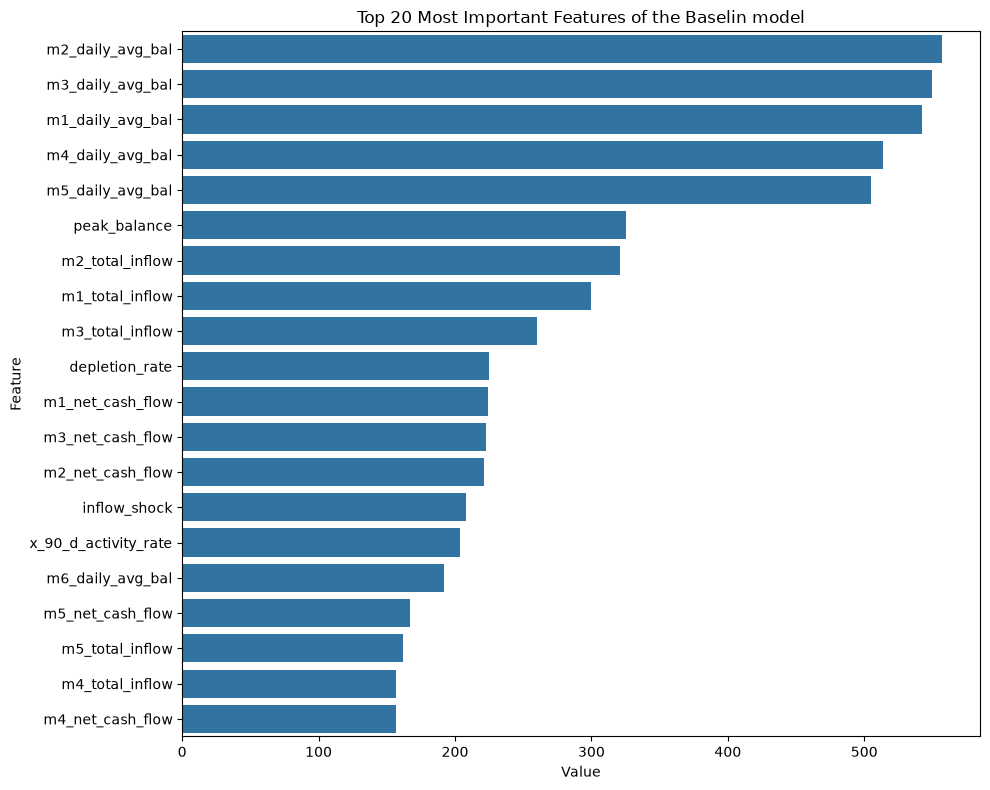

In [3]:
feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': X.columns})
plt.figure(figsize=(10, 8))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).head(20))
plt.title('Top 20 Most Important Features of the Baselin model')
plt.tight_layout()
plt.show()

## Overfitting Check
The following cell evaluates the final fold's model(s) on both its training set and validation set to visualize the generalization gap. A large gap indicates overfitting.

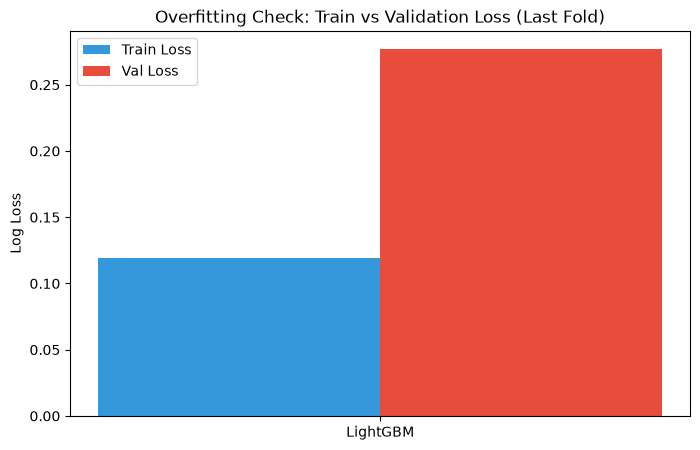

LightGBM - Train: 0.1193, Val: 0.2768, Gap: 0.1575


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss

def check_overfitting():
    try:
        models_to_check = {}
        if 'model_lgb' in globals(): models_to_check['LightGBM'] = model_lgb
        if 'model_cb' in globals(): models_to_check['CatBoost'] = model_cb
        if 'model_xgb' in globals(): models_to_check['XGBoost'] = model_xgb
        if 'model' in globals() and 'LGBM' in str(type(model)): models_to_check['LightGBM'] = model
        
        if not models_to_check:
            print("No standard models found in memory to check.")
            return
            
        if 'X_train' not in globals() or 'X_val' not in globals():
            print("X_train or X_val not found in memory.")
            return
            
        train_losses = []
        val_losses = []
        names = []
        
        for name, m in models_to_check.items():
            train_p = m.predict_proba(X_train)[:, 1]
            val_p = m.predict_proba(X_val)[:, 1]
            train_losses.append(log_loss(y_train, train_p))
            val_losses.append(log_loss(y_val, val_p))
            names.append(name)
            
        x = range(len(names))
        width = 0.35
        
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar([i - width/2 for i in x], train_losses, width, label='Train Loss', color='#3498db')
        ax.bar([i + width/2 for i in x], val_losses, width, label='Val Loss', color='#e74c3c')
        
        ax.set_ylabel('Log Loss')
        ax.set_title('Overfitting Check: Train vs Validation Loss (Last Fold)')
        ax.set_xticks(x)
        ax.set_xticklabels(names)
        ax.legend()
        plt.show()
        
        for i, name in enumerate(names):
            print(f"{name} - Train: {train_losses[i]:.4f}, Val: {val_losses[i]:.4f}, Gap: {val_losses[i] - train_losses[i]:.4f}")
            
    except Exception as e:
        print(f"Could not run overfitting check: {e}")

check_overfitting()